In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "SPY"]

prices = yf.download(tickers, start="2020-01-01", end="2024-12-31")["Close"]

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Date,,,,,
2020-01-02,72.333870,94.900497,67.832520,151.829529,296.125244
2020-01-03,71.630630,93.748497,67.477654,149.938995,293.882996
2020-01-06,72.201416,95.143997,69.276215,150.326553,295.004120
2020-01-07,71.861855,95.343002,69.142403,148.955917,294.174622
2020-01-08,73.017845,94.598503,69.634537,151.328537,295.742401


In [4]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005232,-0.012452,-0.007572
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.003815
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,-0.002812
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.005329
2020-01-09,0.021241,0.004799,0.010498,0.012493,0.006781


In [5]:
mean_returns = returns.mean() * 252
volatility = returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    "Annual Return": mean_returns,
    "Annual Volatility": volatility
})

summary

,Annual Return,Annual Volatility
Ticker,,
AAPL,0.299545,0.316891
AMZN,0.234575,0.359757
GOOGL,0.259848,0.325080
MSFT,0.250702,0.305068
SPY,0.156493,0.210048


In [6]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Ticker,,,,,
AAPL,1.000000,0.592144,0.648873,0.748290,0.790609
AMZN,0.592144,1.000000,0.647135,0.678451,0.644478
GOOGL,0.648873,0.647135,1.000000,0.746133,0.744566
MSFT,0.748290,0.678451,0.746133,1.000000,0.819094
SPY,0.790609,0.644478,0.744566,0.819094,1.000000


In [7]:
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2020-01-03   -0.009423
2020-01-06    0.011182
2020-01-07   -0.003294
2020-01-08    0.007331
2020-01-09    0.011162
dtype: float64

In [8]:
portfolio_annual_return = portfolio_returns.mean() * 252
portfolio_annual_volatility = portfolio_returns.std() * np.sqrt(252)
sharpe_ratio = portfolio_annual_return / portfolio_annual_volatility

portfolio_summary = pd.DataFrame({
    "Metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio"],
    "Value": [
        portfolio_annual_return,
        portfolio_annual_volatility,
        sharpe_ratio
    ]
})

portfolio_summary

,Metric,Value
0,Annual Return,0.240233
1,Annual Volatility,0.264096
2,Sharpe Ratio,0.909640


In [9]:
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod()

portfolio_cumulative_returns.head()

Date
2020-01-03    0.990577
2020-01-06    1.001653
2020-01-07    0.998353
2020-01-08    1.005672
2020-01-09    1.016897
dtype: float64

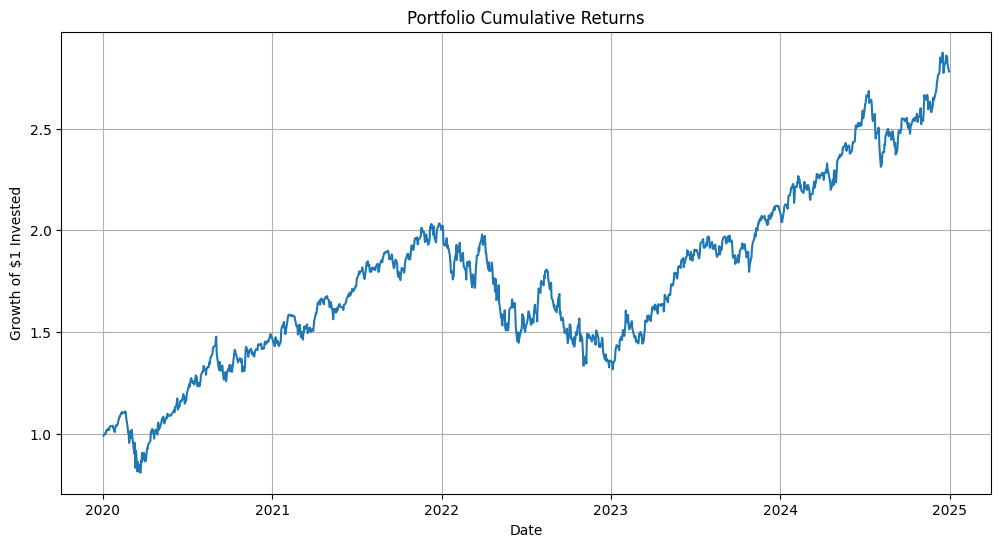

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(portfolio_cumulative_returns)

plt.title("Portfolio Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")

plt.grid(True)
plt.show()

In [11]:
running_max = portfolio_cumulative_returns.cummax()

drawdown = (portfolio_cumulative_returns / running_max) - 1

drawdown.head()

Date
2020-01-03    0.000000
2020-01-06    0.000000
2020-01-07   -0.003294
2020-01-08    0.000000
2020-01-09    0.000000
dtype: float64

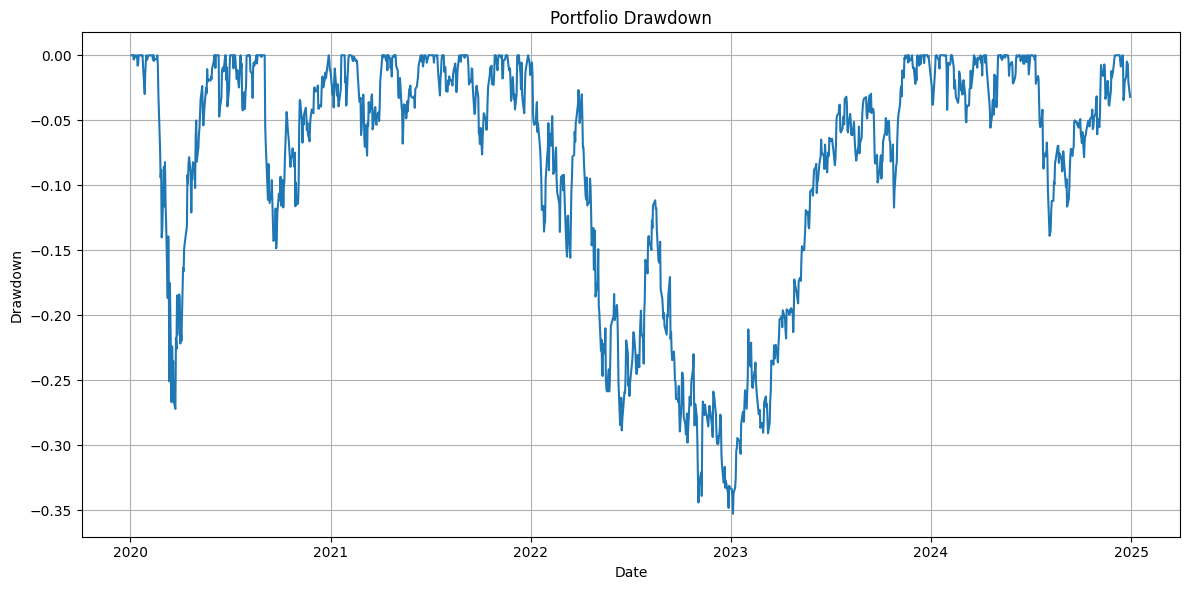

In [12]:
plt.figure(figsize=(12,6))

plt.plot(drawdown)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)
plt.tight_layout()

plt.show()

In [13]:
max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.3526336852247848)

In [14]:
final_summary = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        portfolio_annual_return,
        portfolio_annual_volatility,
        sharpe_ratio,
        max_drawdown
    ]
})

final_summary

,Metric,Value
0,Annual Return,0.240233
1,Annual Volatility,0.264096
2,Sharpe Ratio,0.909640
3,Maximum Drawdown,-0.352634


In [15]:
final_summary.to_csv("../data/portfolio_summary.csv", index=False)

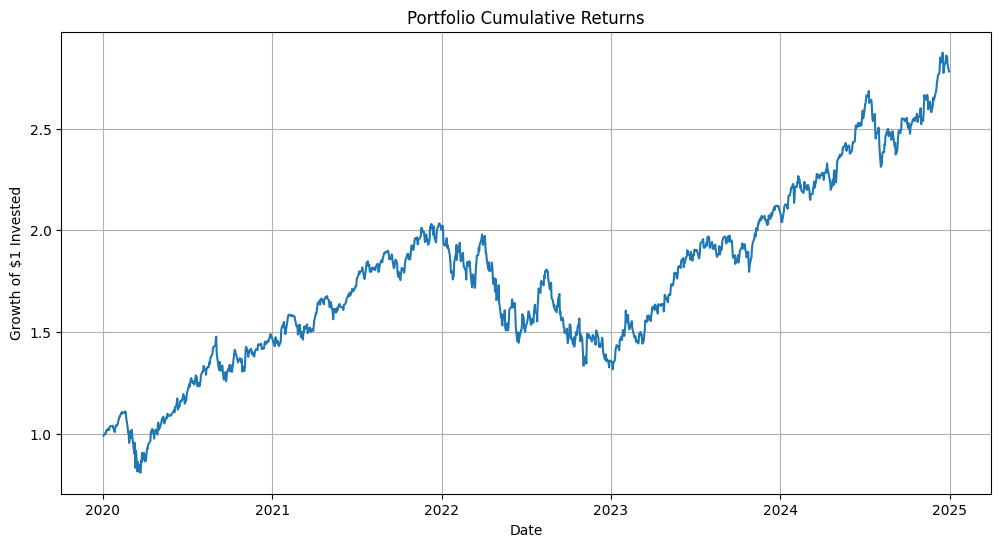

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(portfolio_cumulative_returns)

plt.title("Portfolio Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")

plt.grid(True)

plt.savefig("../images/portfolio_cumulative_returns.png", bbox_inches="tight")

plt.show()

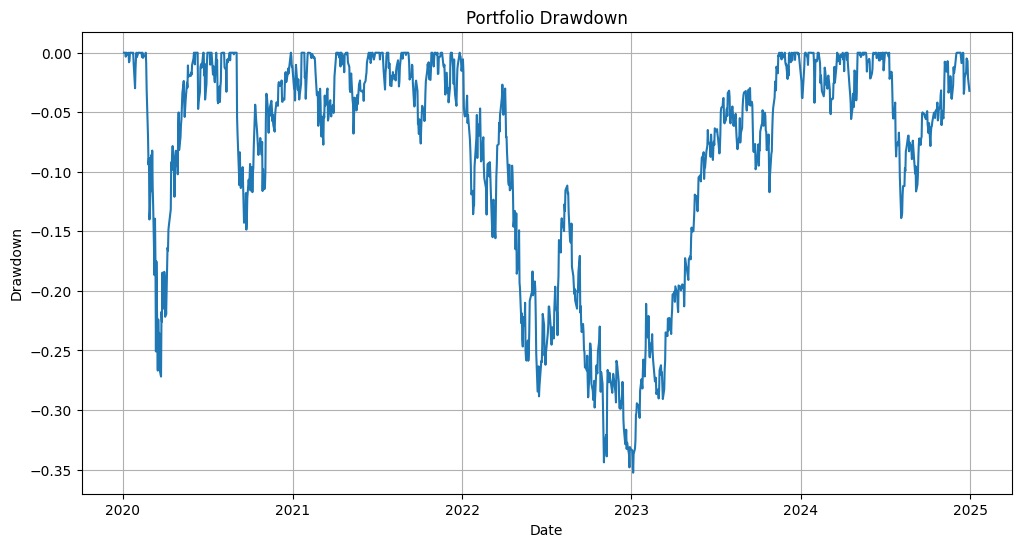

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(drawdown)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)

plt.savefig("../images/portfolio_drawdown.png", bbox_inches="tight")

plt.show()